In [1]:
import numpy as np
import pandas as pd
# import matplotlib.pyplot as plt
from sklearn.preprocessing import scale 
from sklearn import model_selection
from sklearn.model_selection import RepeatedKFold
from sklearn.model_selection import train_test_split
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error
from sklearn import model_selection
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sys import stdout
import numpy as np
import pandas as pd
# import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import csv
from scipy.signal import savgol_filter
from scipy.stats import pearsonr
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df_svc_RDMC=  pd.read_csv(r"E:\wenqu\2026_root\add_pft_aboveground\add_aboveground_pft\root_trait_RDMC.csv")
df_svc_SRL=  pd.read_csv(r"E:\wenqu\2026_root\add_pft_aboveground\add_aboveground_pft\root_trait_SRL.csv")
df_svc_RTD =  pd.read_csv(r"E:\wenqu\2026_root\add_pft_aboveground\add_aboveground_pft\outliers\root_trait_RTD.csv")
df_svc_RD=  pd.read_csv(r"E:\wenqu\2026_root\add_pft_aboveground\add_aboveground_pft\root_trait_RD.csv")
df_svc_SRA= pd.read_csv(r"E:\wenqu\2026_root\add_pft_aboveground\add_aboveground_pft\root_trait_SRA.csv")
df_svc_RBD=  pd.read_csv(r"E:\wenqu\2026_root\add_pft_aboveground\add_aboveground_pft\root_trait_RBD.csv")
df_svc_RLD=  pd.read_csv(r"E:\wenqu\2026_root\add_pft_aboveground\add_aboveground_pft\outliers\root_trait_RLD.csv")

df_svc_RCC=  pd.read_csv(r"E:\wenqu\2026_root\add_pft_aboveground\add_aboveground_pft\root_trait_RCC.csv")
df_svc_RD13C = pd.read_csv(r"E:\wenqu\2026_root\add_pft_aboveground\add_aboveground_pft\root_trait_RD13C.csv")
df_svc_RNC =  pd.read_csv(r"E:\wenqu\2026_root\add_pft_aboveground\add_aboveground_pft\root_trait_RNC.csv")
df_svc_RD15N=  pd.read_csv(r"E:\wenqu\2026_root\add_pft_aboveground\add_aboveground_pft\root_trait_RD15N.csv")
df_svc_RCN= pd.read_csv(r"E:\wenqu\2026_root\add_pft_aboveground\add_aboveground_pft\root_trait_RCN.csv")
df_svc_RCC= pd.read_csv(r"E:\wenqu\2026_root\add_pft_aboveground\add_aboveground_pft\outliers\root_trait_RCC.csv")


In [3]:
b_name = []

for i in range(1, 122):
    b_mean = 'b' + str(i) 
    b_name.append(b_mean)
    b_std = 'b' + str(i) + '_std'
    b_name.append(b_std)


# b_name = np.array(b_name)
# b_name

In [4]:
cols_rdmc = b_name + ["CWM_log10_LDMC", "DS_relative_abund_sum", "ES_relative_abund_sum", "F_relative_abund_sum", "G_relative_abund_sum", "M_relative_abund_sum"]
cols_srl = b_name+ ["CWM_log10_SLA"]+ ["CWM_log10_LA"]+ ["CWM_log10_LDMC"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]

cols_rtd = b_name+ ["CWM_log10_SLA"] + ["CWM_log10_LDMC"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]

cols_rd = b_name+ ["CWM_log10_LDMC"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]


cols_sra = b_name + ["CWM_log10_SLA"] + ["CWM_log10_LDMC"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]
cols_rbd = b_name+ ["CWM_log10_LA"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]
cols_rld = b_name+ ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]

cols_rcc = b_name+ ["CWM_log10_PC"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]
cols_rd13c = b_name+ ["CWM_Ld13C"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]
cols_rnc = b_name+ ["CWM_log10_PN"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]

cols_rd15n = b_name+ ["CWM_Ld15N"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]

cols_rcn = b_name+ ["CN_ratio"] + ["DS_relative_abund_sum"]+ ["ES_relative_abund_sum"]+ ["F_relative_abund_sum"]+ ["G_relative_abund_sum"]+ ["M_relative_abund_sum"]

In [5]:
x_RDMC = np.array(df_svc_RDMC[cols_rdmc] )
x_SRL = np.array(df_svc_SRL[cols_srl])
x_RTD = np.array(df_svc_RTD[cols_rtd])
x_RD = np.array(df_svc_RD[cols_rd])
x_SRA = np.array(df_svc_SRA[cols_sra])
x_RBD = np.array(df_svc_RBD[cols_rbd])
x_RLD = np.array(df_svc_RLD[cols_rld])
x_RD13C = np.array(df_svc_RD13C[cols_rd13c])
x_RNC = np.array(df_svc_RNC[cols_rnc])
x_RD15N = np.array(df_svc_RD15N[cols_rd15n])
x_RCN = np.array(df_svc_RCN[cols_rcn])
x_RCC = np.array(df_svc_RCC[cols_rcc])

In [6]:
labels_RDMC = [] 
for i in range(len(df_svc_RDMC['site'])):    
    site_name = df_svc_RDMC['site'][i].split("_")[0]
    labels_RDMC.append(site_name)


labels_SRL = [] 
for i in range(len(df_svc_SRL['site'])):    
    site_name = df_svc_SRL['site'][i].split("_")[0]
    labels_SRL.append(site_name)


labels_RTD = [] 
for i in range(len(df_svc_RTD['site'])):    
    site_name = df_svc_RTD['site'][i].split("_")[0]
    labels_RTD.append(site_name)

In [7]:
labels_RD = [] 
for i in range(len(df_svc_RD['site'])):    
    site_name = df_svc_RD['site'][i].split("_")[0]
    labels_RD.append(site_name)
# labels_pc

labels_SRA = [] 
for i in range(len(df_svc_SRA['site'])):    
    site_name = df_svc_SRA['site'][i].split("_")[0]
    labels_SRA.append(site_name)


labels_RBD = [] 
for i in range(len(df_svc_RBD['site'])):    
    site_name = df_svc_RBD['site'][i].split("_")[0]
    labels_RBD.append(site_name)

In [8]:
labels_RLD = [] 
for i in range(len(df_svc_RLD['site'])):    
    site_name = df_svc_RLD['site'][i].split("_")[0]
    labels_RLD.append(site_name)
# labels_pc

labels_RD13C = [] 
for i in range(len(df_svc_RD13C['site'])):    
    site_name = df_svc_RD13C['site'][i].split("_")[0]
    labels_RD13C.append(site_name)


labels_RNC = [] 
for i in range(len(df_svc_RNC['site'])):    
    site_name = df_svc_RNC['site'][i].split("_")[0]
    labels_RNC.append(site_name)


labels_RD15N = [] 
for i in range(len(df_svc_RD15N['site'])):    
    site_name = df_svc_RD15N['site'][i].split("_")[0]
    labels_RD15N.append(site_name)


labels_RCN = [] 
for i in range(len(df_svc_RCN['site'])):    
    site_name = df_svc_RCN['site'][i].split("_")[0]
    labels_RCN.append(site_name)



labels_RCC = [] 
for i in range(len(df_svc_RCC['site'])):    
    site_name = df_svc_RCC['site'][i].split("_")[0]
    labels_RCC.append(site_name)

In [9]:
y_RDMC = df_svc_RDMC['RDMC_A'].to_numpy()
y_SRL = df_svc_SRL['SRL'].to_numpy()
y_RTD = df_svc_RTD['RTD'].to_numpy()
y_RD = df_svc_RD['RD'].to_numpy()
y_SRA = df_svc_SRA['SRA'].to_numpy()
y_RBD = df_svc_RBD['RBD'].to_numpy()
y_RLD = df_svc_RLD['RLD'].to_numpy()
y_RCC = df_svc_RCC['RCC'].to_numpy()
y_RD13C = df_svc_RD13C['Rd13C'].to_numpy()

y_RNC = df_svc_RNC['RNC'].to_numpy()
y_RD15N = df_svc_RD15N['Rd15N'].to_numpy()
y_RCN = df_svc_RCN['RCN'].to_numpy()

In [10]:
def optimise_pls_band_component(X, y, max_comp):
    
    # Define an MSE array to be populated
    mse = np.zeros((max_comp, X.shape[1] - max_comp +1 ))



    # Loop over the number of PLS components
    for i in range(max_comp):
        # print(i)
        
        # Regression with the specified number of components, using the full spectrum
        pls1 = PLSRegression(n_components=i + 1)
        pls1.fit(X, y)
        
        # Indices of sorted spectra according to ascending absolute value of PLS coefficients
        sorted_ind = np.argsort(np.abs(pls1.coef_.flatten()))
 
        # Sort spectra accordingly
        Xc = X[:, sorted_ind]
        
        max_j = min(Xc.shape[1] - (i + 1), mse.shape[1]) 
        # Discard one wavelength at a time from the sorted spectra,
        # regress, and calculate the MSE cross-validation
        for j in range(max_j): 
            pls2 = PLSRegression(n_components=i + 1)
            pls2.fit(Xc[:, j:], y)
            
            y_cv = cross_val_predict(pls2, Xc[:, j:], y.astype(np.float64), cv=10)
          

            mse[i, j] = np.sqrt(mean_squared_error(y, y_cv))        
            

      

    
    stdout.write("\n")
    
    # Find the indices of the minimum non-NaN MSE values
    mseminx,mseminy = np.where(mse==np.min(mse[np.nonzero(mse)]))

    
    print("Optimised number of PLS components: ", mseminx[0] + 1)
    print("Wavelengths to be kept ", (X.shape[1] - mseminy[0]))
    print('Optimised MSEP ', mse[mseminx, mseminy][0])
    stdout.write("\n")
 
    # Calculate PLS with optimal components and export values
    optimal_pls = PLSRegression(n_components=mseminx[0] + 1)
    optimal_pls.fit(X, y)
        
    sorted_ind = np.argsort(np.abs(optimal_pls.coef_.flatten()))
 
    Xc = X[:, sorted_ind]
 
    return Xc[:, mseminy[0]:], mseminx[0] + 1, mseminy[0], sorted_ind

In [11]:


def simple_pls_cv_label_category(X, y, n_comp, labels, filename):

    # Run PLS with suggested number of components
    pls = PLSRegression(n_components=n_comp)
    pls.fit(X, y)
    y_c = pls.predict(X)
    print(y_c)

    # Cross-validation
    y_cv = cross_val_predict(pls, X, y, cv=10)


    # Calculate scores for calibration and cross-validation
    score_c = r2_score(y, y_c)
    score_cv = r2_score(y, y_cv)

    # Calculate mean square error for calibration and cross validation
#     mse_c = mean_squared_error(y, y_c)
#     mse_cv = mean_squared_error(y, y_cv)
    rmse_c = np.sqrt(mean_squared_error(y, y_c))

    rmse_cv = np.sqrt(mean_squared_error(y, y_cv))  


    print('R2 calib: %5.3f'  % score_c)
    print('R2 CV: %5.3f'  % score_cv)
#     print('MSE calib: %5.3f' % mse_c)
#     print('MSE CV: %5.3f' % mse_cv)
    print('RMSE calib: %5.3f' % rmse_c)
    print('RMSE CV: %5.3f' % rmse_cv)

    # Plot regression 
    z = np.polyfit(y, y_cv, 1)
    print(z[1],z[0])
    with plt.style.context(('ggplot')):
        fig, ax = plt.subplots(figsize=(9, 5))

        # Define a dictionary of labels and their corresponding markers and colors
        # Define label styles
        label_dict = {
            'S3C': {'marker': 'o', 'color': 'purple'},     # circle
            'S4' : {'marker': 's', 'color': 'blue'},       # square
            'S6' : {'marker': 'D', 'color': 'orange'},     # diamond
            'S6A': {'marker': 'p', 'color': 'cyan'},       # pentagon
            'S7' : {'marker': '^', 'color': 'brown'},      # triangle up
            'S2C': {'marker': 'v', 'color': 'green'},      # triangle down
            'S1B': {'marker': 'X', 'color': 'red'},        # X
            'S2A': {'marker': '*', 'color': 'magenta'}   
            
        }

        # Loop over data points to add labels and build a list of scatter plot objects
        scatter_objs = []
        with open(filename, 'w', newline='') as csvfile:
            csvwriter = csv.writer(csvfile)
            for i, label in enumerate(labels):
                print(i, label, y_cv[i], y[i])
                csvwriter.writerow([i, label, y_cv[i], y[i]])
            
            
        for i, label in enumerate(labels):
            default_style = {'marker': '*', 'color': 'purple'}
            style = label_dict.get(label, default_style)
            scatter_obj = ax.scatter(y_cv[i], y[i], marker=style['marker'],
                             c=style['color'], edgecolors='k')
            scatter_objs.append(scatter_obj)
            
            
#             scatter_obj = ax.scatter(y_cv[i], y[i], marker=label_dict.get(label, label_dict['S6A'])['marker'],
#                                      c=label_dict.get(label, label_dict['S6A'])['color'], edgecolors='k')
#             scatter_objs.append(scatter_obj)

        # Create a legend using the dictionary of labels and their markers/colors
        legend_handles = []
        for label, props in label_dict.items():
            legend_handles.append(plt.Line2D([], [], marker=props['marker'], color=props['color'], linestyle='None', label=label))
        ax.legend(handles=legend_handles)

        ax.plot(z[1]+z[0]*y, y, c='blue', linewidth=1)
        ax.plot(y, y, color='green', linewidth=1)
        plt.title('$R^{2}$ (CV): '+str(score_cv))
        plt.xlabel('Predicted $^{\circ}$Brix')
        plt.ylabel('Measured $^{\circ}$Brix')
        plt.show()


## RDMC

In [19]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RDMC, y_RDMC, 25)


Optimised number of PLS components:  18
Wavelengths to be kept  84
Optimised MSEP  49.361603429989856



[195.02460757 191.54026995 311.83363009 242.47133835 290.26524352
 318.89714477 214.32250397 230.64349145 203.50018858 259.80375287
 245.24696317 245.85274388 284.82447309 235.76155984 352.22517175
 197.8520219  253.87099321 293.53648872 199.94452153 326.69588905
 335.3999535  214.41943845 362.96784816 191.64543179 218.09356968
 297.12528288 369.62367098 352.59760202 341.28275135 272.61812968
 276.60299093 409.47271312 302.2622672  385.11574863 372.54853259
 363.06946042 362.41006275 282.11361371 280.21849193 306.97220409
 331.51414789 345.12788727 329.6931261  337.10487823 316.98935783
 332.30589048 325.22498325 321.42997408 337.46712723 322.8851484
 302.65055588 315.25277306 328.80089424 324.94163538 338.00051862
 316.0134373  327.89428272 331.89612209 327.80616224 322.96673408
 310.38295196 316.42393593 302.16432728 319.56020002 340.50864291
 336.78599334 318.76741262 345.78418638 332.03537165 323.17509635
 292.35418985 328.65375797 312.36712811 346.00007514 352.69269617
 313.682892

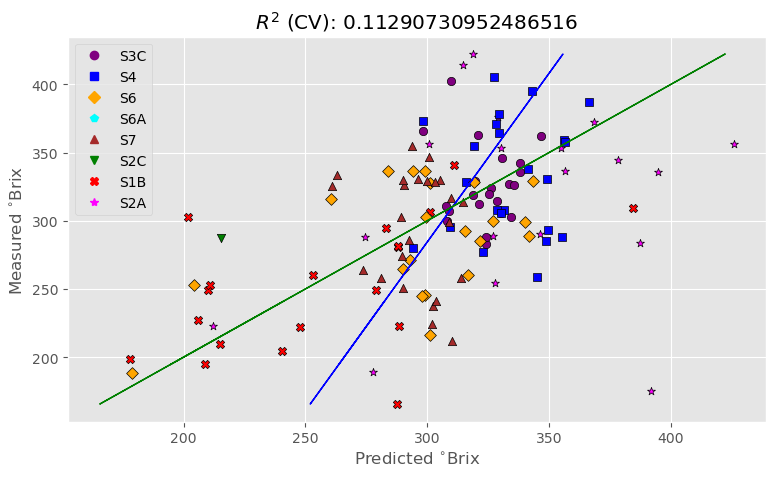

In [20]:
file_name_sla = r'E:\wenqu\2026_root\CSV\RDMC.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RDMC,                         
                             ncomp, labels_RDMC, file_name_sla)

## SRL

In [21]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_SRL, y_SRL, 20)


Optimised number of PLS components:  10
Wavelengths to be kept  23
Optimised MSEP  31.897300965608785



[ 85.27362517  94.17413162 114.20621659 120.69570559 108.44524921
 105.03292761 108.91630297 120.40689256 121.22855665 114.02436695
 110.69495093 108.82846882 114.62891063 127.46444222 113.87399452
 112.84961229 131.52169626 130.65562683 101.05960851  30.3921031
  58.5877617   38.18946749  24.88335673  52.18900864  44.10498576
  60.07895534   4.64280359  65.09187281  61.90835186  59.3256072
  46.91391059  58.71093681  38.93718565  67.84380128  52.85494058
  30.58614132  81.60304953 132.96313445 146.30678838 113.91023636
 119.47272141 147.44461571 128.73779503 120.7760322  124.15893289
 129.41467333 131.8768241  157.40881286 132.91077041 129.00746874
 132.72067658 138.02061524 132.16059498 125.64212145 124.00911897
 123.43335171 137.27227245  88.96529231 124.24484163 133.54997632
 130.27491192 134.13721583 129.39348486 138.77053536 141.5251188
 138.89535759 121.29437421 143.81494749 128.99656146 144.93638292
 132.20021877 146.089306   157.56031714 112.28995573 132.81400087
 143.18772763

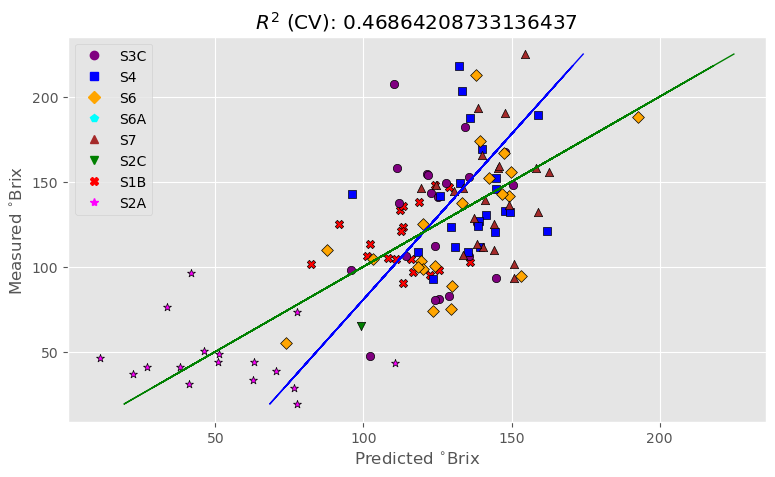

In [22]:
file_name_sla = r'E:\wenqu\2026_root\CSV\SRL.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_SRL,                         
                             ncomp, labels_SRL, file_name_sla)

## RTD
 

In [12]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RTD, y_RTD, 30)


Optimised number of PLS components:  20
Wavelengths to be kept  49
Optimised MSEP  0.0716725971603244



[0.30642012 0.30698454 0.25729234 0.39102863 0.47774763 0.40326685
 0.41741344 0.32970035 0.3952116  0.38379562 0.40673248 0.45203529
 0.5943326  0.47265739 0.57949761 0.4963239  0.47770299 0.45880632
 0.4701234  0.30448419 0.25746818 0.34286777 0.62647225 0.53081463
 0.60993829 0.40993471 0.59780049 0.46906427 0.57243539 0.50604991
 0.36046166 0.54429378 0.45977848 0.57174838 0.29234298 0.4743253
 0.51128863 0.47063354 0.48850292 0.4830605  0.46784114 0.49028851
 0.40760514 0.46019816 0.4984707  0.452512   0.43520497 0.48008499
 0.47848454 0.46688238 0.46252575 0.46396612 0.47761491 0.44959361
 0.45328416 0.44672072 0.52103743 0.53347376 0.54679696 0.56349621
 0.52638348 0.53657159 0.53488875 0.51807988 0.49186449 0.51354908
 0.54681245 0.54717704 0.547056   0.43132467 0.54104062 0.58136229
 0.56283037 0.52389112 0.50277052 0.56629084 0.55536031 0.49717265
 0.61106754 0.48834644 0.45032891 0.46262008 0.45921102 0.40341347
 0.42350515 0.43860681 0.44004595 0.43610626 0.40978742 0.44936

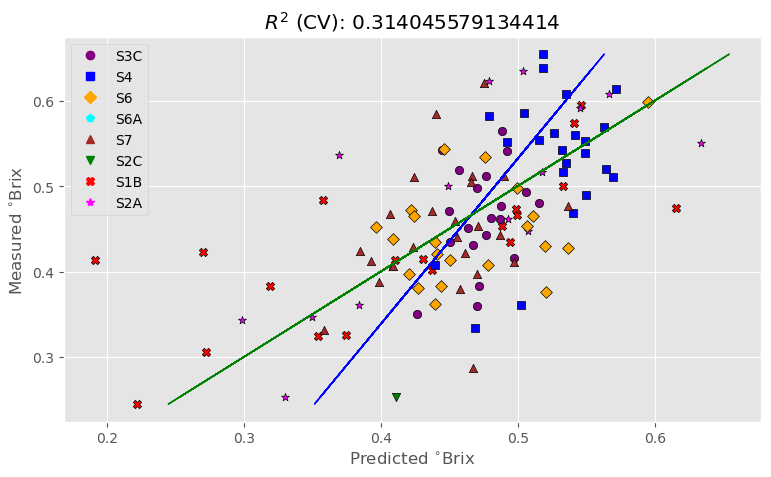

In [13]:
file_name_sla = r'E:\wenqu\2026_root\CSV\RTD.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RTD,                         
                             ncomp, labels_RTD, file_name_sla)

In [13]:
df_svc_sla['site'][51]

'S6_Q23'

## RD

In [25]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RD, y_RD, 20)


Optimised number of PLS components:  18
Wavelengths to be kept  58
Optimised MSEP  0.026042139865091855



[0.13374801 0.12148247 0.13056473 0.13322532 0.14737397 0.13560228
 0.13526338 0.12974636 0.12931476 0.12923885 0.1498682  0.13974108
 0.13389023 0.12384224 0.13516778 0.13865923 0.15850452 0.13386152
 0.13936155 0.1350799  0.13996929 0.1301513  0.12827991 0.13108303
 0.14244957 0.11930808 0.12216078 0.13741993 0.14855242 0.12566382
 0.12982573 0.15388478 0.13496756 0.14733116 0.13858801 0.13248131
 0.12819562 0.135483   0.13867953 0.13977788 0.15537155 0.14564188
 0.14969444 0.13430297 0.1313839  0.14110294 0.12748962 0.14138431
 0.14029973 0.15072085 0.15271233 0.14303784 0.15382128 0.13054898
 0.14168575 0.14075927 0.12244959 0.1506101  0.14218557 0.16131084
 0.14271086 0.14236901 0.16121378 0.16389221 0.15955346 0.13998081
 0.15241333 0.1612098  0.17545284 0.14479179 0.14996578 0.14582188
 0.14423025 0.16297861 0.15880211 0.15795479 0.14953978 0.17356762
 0.17052605 0.16897361 0.18200689 0.173272   0.16980079 0.13412325
 0.15647695 0.15255939 0.16150384 0.16704709 0.18671446 0.1473

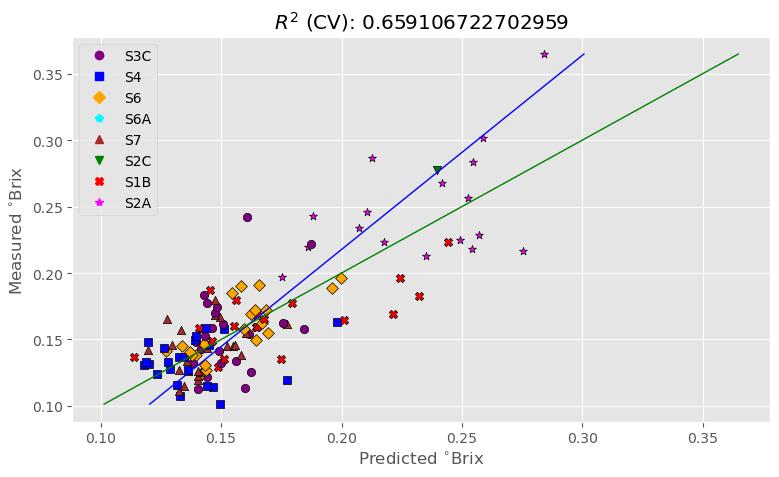

In [26]:
file_name_sla = r'E:\wenqu\2026_root\CSV\RD.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RD,                         
                             ncomp, labels_RD, file_name_sla)

In [13]:
df_svc_d13c['site'][53]

'S6_Q27'

# SRA

In [27]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_SRA, y_SRA, 25)


Optimised number of PLS components:  22
Wavelengths to be kept  33
Optimised MSEP  102.61149552423113



[598.44529508 656.55014628 690.60369546 585.56631009 487.3442556
 543.51696612 504.60138815 741.39001349 558.23436406 676.79836971
 518.54108117 544.64529694 514.4879267  625.60497679 531.54266051
 599.29265336 636.23179223 459.53233898 525.39612614 440.8969781
 672.967878   472.22674332 231.44545591 309.04434003 240.91280931
 370.64323109 299.49349972 370.57336748 348.5070856  218.60342974
 406.70569161 305.92283561 322.3367779  440.21214642 275.00244148
 239.03469962 542.99376811 598.84754288 548.98583544 549.99609742
 566.93840334 550.776677   620.36440037 543.91474044 647.67864255
 620.63308478 583.25459975 585.37022385 623.39924814 625.02786342
 586.90955785 518.03994151 594.51304978 585.77670418 568.93735207
 572.68978308 596.20407468 624.46462885 664.90321525 598.83808671
 563.43183226 542.80597877 526.7182568  578.82034799 558.10434866
 576.97710854 590.24035437 629.68893331 581.09276013 593.17464314
 527.57398859 538.37168162 667.37150317 564.22327712 504.75077128
 529.4823066

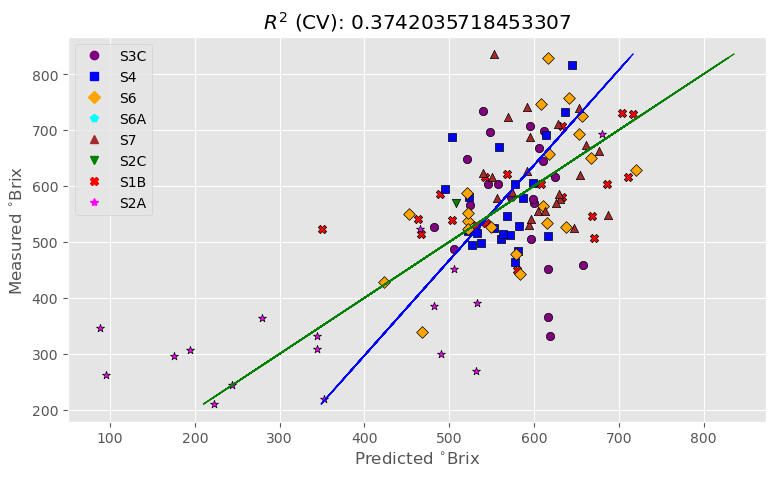

In [28]:

file_name_sla = r'E:\wenqu\2026_root\CSV\SRA.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_SRA,                         
                             ncomp, labels_SRA, file_name_sla)

In [13]:
df_svc_d15n['site'][91]

'S2A_Q17'

## RBD

In [29]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RBD, y_RBD, 25)



Optimised number of PLS components:  20
Wavelengths to be kept  81
Optimised MSEP  0.0034499367888672764



[ 0.00772315  0.007563    0.00680362  0.01730822  0.01159348  0.00928324
  0.00876394  0.00608824  0.0132778   0.00281883  0.00396032  0.01218746
  0.01301231  0.00915212  0.01831218  0.00303029  0.00263161  0.00834962
  0.002288    0.00203158  0.00465781  0.00093199  0.00074621  0.00212296
  0.00087369  0.00224006  0.00314179  0.00608753  0.00586583  0.00063686
  0.00541781  0.01278543  0.00332684  0.00095427  0.00040281  0.0093555
  0.00648179  0.00263641 -0.00080273  0.00293704  0.00283258  0.00461403
  0.00147523  0.00263371  0.00425829  0.00370824  0.0039207   0.00263767
  0.00690525  0.00409213  0.00283676  0.00223494  0.00126711  0.00193645
  0.00250609  0.00079288  0.00280143  0.00418965  0.00260866  0.00111064
  0.00030372  0.00218659  0.0018575   0.00329068  0.00412664  0.00262887
  0.00329314  0.00076478  0.00299792  0.00352145  0.00206913  0.00378149
  0.00030468 -0.00091008  0.00258022  0.00278685  0.00301783  0.00398344
  0.00299313  0.00561099  0.00603831  0.00500749]
R2

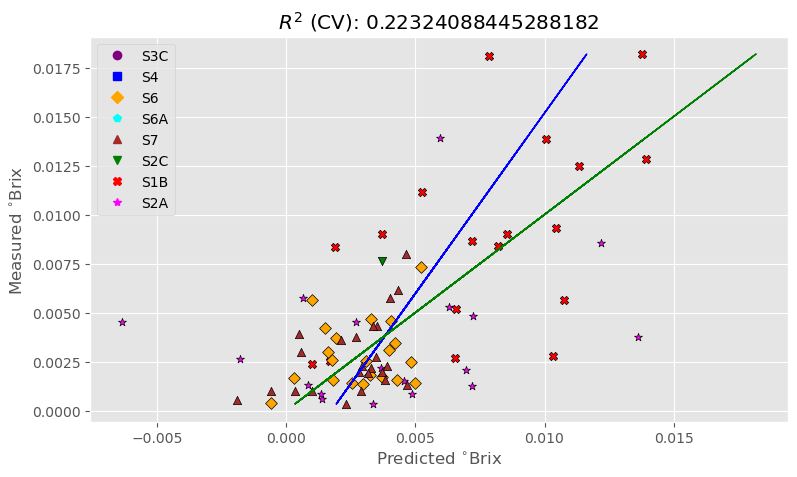

In [30]:
file_name_sla = r'E:\wenqu\2026_root\CSV\RBD.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RBD,                         
                             ncomp, labels_RBD, file_name_sla)

In [14]:
df_svc_RBD['site'][29]

'S2A_Q17'

## RLD

In [12]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RLD, y_RLD, 20)


Optimised number of PLS components:  9
Wavelengths to be kept  56
Optimised MSEP  2.77707283602106



[ 0.16571041  3.45424101  0.61991458  1.61221455  0.31411302  1.38127488
  1.6697059   2.70736842  6.4511712   1.10956549  1.58497672  1.51649497
  1.95046259  3.29962175  3.35004542  1.7477551   2.60121665  3.14074
  2.9271777   3.48981203  2.47731487  3.69128531  2.14853218  3.12198469
  5.30628697  3.09961211  4.98252686  3.40475649  8.55473293  4.1638494
  2.50561594  2.98757592  3.42990519  2.56088202  5.85111933  4.16464153
  6.4689789   4.64078167  3.9332026   5.79950676  2.90760552  6.11431393
  5.12120345  5.41901008  5.26640508  5.60471688  5.7383735   5.51118926
  5.92391704  5.83937843  5.72023257  5.93298208  8.83207191  7.83599656
  3.61058895  5.88785258  4.52862273  3.44500423  5.17558925  8.24034751
  3.87046619  4.95491068  4.94406719  6.47999     6.45986277  4.3087368
  4.85335726  4.82488612  8.94168976  6.24085666  7.82201712  6.46062659
  4.64561365  8.0863849   8.64385812  5.05063145  8.18597107  5.89106284
  7.27668397  5.44564833  6.01674923  8.78606497  5.8057

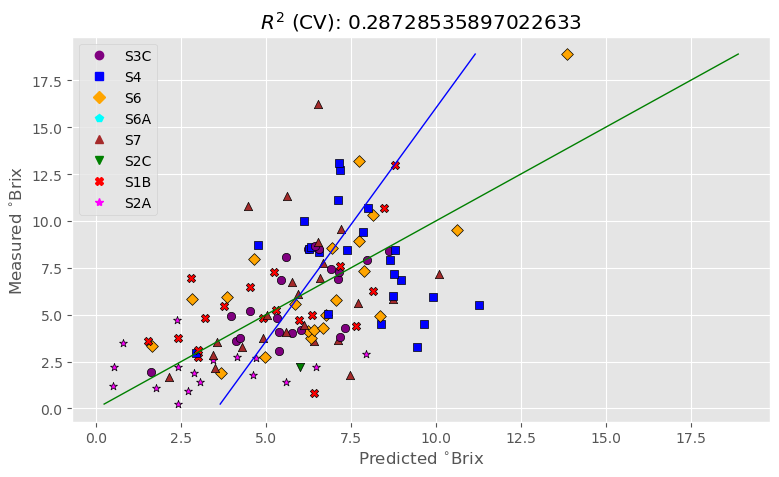

In [32]:

file_name_sla = r'E:\wenqu\2026_root\CSV\RLD.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RLD,                         
                             ncomp, labels_RLD, file_name_sla)

## RD13C

In [33]:

opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RD13C, y_RD13C, 25)


Optimised number of PLS components:  16
Wavelengths to be kept  107
Optimised MSEP  0.8235454971110251



[-28.32291085 -28.13847326 -27.44984694 -28.48508598 -29.06709752
 -29.01140643 -28.05171726 -28.08146848 -29.02283747 -27.48275682
 -27.67737594 -29.13190927 -28.40497515 -27.2148163  -28.41480277
 -27.93724687 -28.10850689 -28.00817072 -28.08854616 -27.38562334
 -29.13433397 -26.16651345 -26.96694884 -27.88081762 -25.99568065
 -28.86784877 -28.55544113 -27.93649707 -28.3588136  -28.06549182
 -28.96003123 -28.35629854 -27.5668201  -26.56648476 -28.82748961
 -27.63303552 -28.16616309 -27.97915977 -29.39628813 -27.4556519
 -28.38640297 -26.34544671 -27.89070179 -26.28642741 -28.41283412
 -27.29727061 -27.92887889 -27.12903928 -27.57211158 -26.83875236
 -28.27894199 -27.22785568 -28.04842527 -27.99326714 -27.67187314
 -27.77872343 -27.55264792 -27.35051482 -27.93520811 -27.5757377
 -27.55837915 -27.55553986 -27.52042884 -27.65728609 -29.78558606
 -27.94779672 -27.71741916 -27.87362724 -28.08956412 -28.34703179
 -28.68401496 -28.326856   -27.91823327 -27.57669348 -28.17309535
 -28.0233297

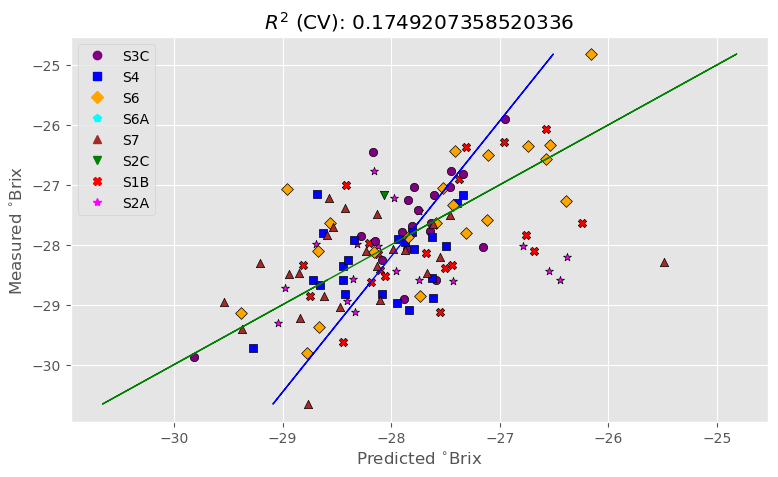

In [34]:

file_name_sla = r'E:\wenqu\2026_root\CSV\RD13C.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RD13C,                         
                             ncomp, labels_RD13C, file_name_sla)

In [17]:
df_svc_RD13C['site'][10]

'S2A_Q15'

## RNC


Optimised number of PLS components:  10
Wavelengths to be kept  33
Optimised MSEP  1.6195087286450054

[11.03784299 12.86545144  9.96026329  8.71423022  9.51635333 12.83015522
 10.68017182  9.93849773  8.77460237  7.21873015  9.12299669  7.79937205
  9.65967616  7.51119192 11.67524756  6.64612373  7.38611953  8.99219335
  7.76474028  7.39148451  9.11939705 11.18678942  8.71845634  7.07236194
  9.90158135 10.94046792 10.68545937 10.85571088 10.77008327 13.60700492
 13.1206859  11.9505978  10.54725254 13.54119492 10.74999249  9.93890362
  7.87957403  9.96275021 11.82109982 13.52036168  9.14629192  8.97456671
  9.48483142  8.75593952  8.8146878   9.74143524  9.57173025 10.47869966
 10.88101906  9.60545172 10.37966293  9.94692882 10.70686595 10.0057924
 10.07689111 10.95725925 10.28011002 10.54613149  9.92366528 10.22403814
  9.90695906  9.88254525 10.12485496 10.03407256 10.48783012 10.16113107
 12.30174577 11.68027366 11.16524863  9.87836921  9.68808432 10.18302725
 10.53384029 10.04697

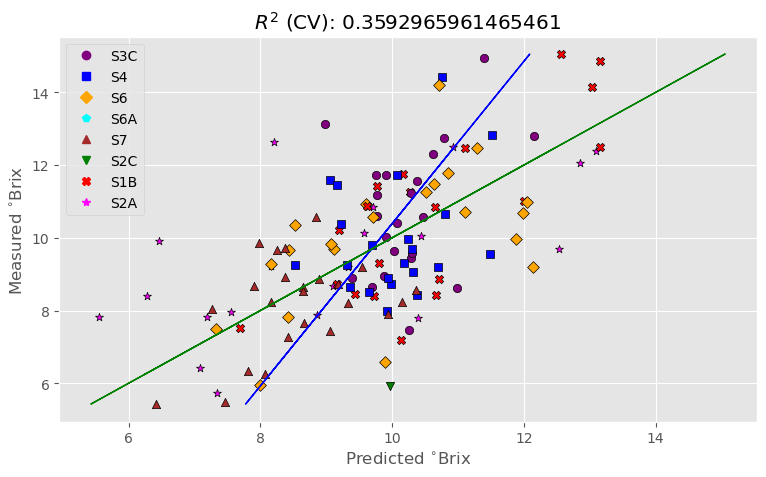

In [35]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RNC, y_RNC, 20)
file_name_sla = r'E:\wenqu\2026_root\CSV\RNC.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RNC,                         
                             ncomp, labels_RNC, file_name_sla)

## RD15N


Optimised number of PLS components:  20
Wavelengths to be kept  77
Optimised MSEP  1.2246401878083883

[ 1.74679490e+00  5.27527723e-01  1.53573162e+00  2.40262450e+00
  1.03590028e+00  2.18081583e+00  2.03489748e-01 -1.71425428e+00
 -1.04025882e+00 -1.44598018e+00 -1.16598848e+00 -2.35570541e-01
  6.18778620e-01 -4.41265342e+00  3.57357617e-01 -4.37481210e+00
  9.53467755e-02 -7.29230261e-01 -3.34256318e+00 -3.39827440e-01
  1.93450620e+00 -3.32801675e+00  1.97815096e+00  2.74843618e+00
  3.51494808e+00  2.06552059e+00 -1.52876945e-01  3.84947883e-01
  2.43656821e+00  5.22288638e-01  1.70169489e+00  2.47936834e+00
  1.84187513e+00  2.17822771e+00  1.68395430e+00  4.00724884e+00
  1.67064725e+00 -9.40235419e-01 -1.48440980e+00  2.08694617e+00
 -1.58067398e-01  2.68406912e+00  5.46523430e-01 -3.73183771e-01
  1.08243007e-01  6.70719307e-01  3.35736086e-01 -9.25277503e-01
  8.51246889e-01  8.79321327e-01  4.84060932e-01  3.73130411e-01
  1.18222460e-01  6.86114669e-01 -2.10810650e-01 -6

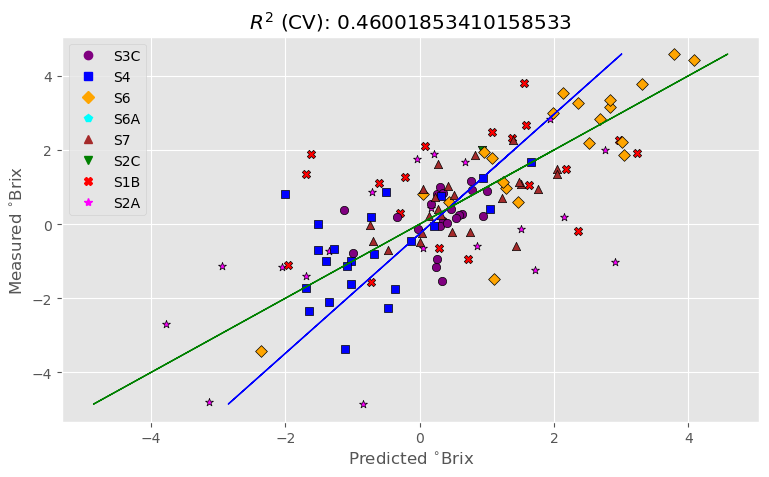

In [36]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RD15N, y_RD15N, 20)
file_name_sla = r'E:\wenqu\2026_root\CSV\RD15N.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RD15N,                         
                             ncomp, labels_RD15N, file_name_sla)

## RCN


Optimised number of PLS components:  12
Wavelengths to be kept  30
Optimised MSEP  9.053730238600574

[34.78524628 38.83987735 45.83706479 56.70478664 46.39055989 39.833009
 46.00298292 62.00934457 55.61266937 70.94328408 64.48039984 65.26916053
 54.03623581 73.3185222  46.06239739 65.18296107 68.84108373 51.40679979
 59.95456668 49.34280509 72.14457976 45.96830017 48.2943526  65.63803382
 48.50678769 36.87578924 44.55202159 46.26442433 41.06341248 31.16912463
 33.0676764  36.05360303 40.58914511 35.55274637 43.40142353 52.18997953
 54.18873585 51.58740241 42.88773572 33.67915252 50.02335428 52.9852142
 50.91076803 58.55568107 51.76327328 51.77563714 47.83415944 44.80734439
 42.63603784 47.81373772 46.31344542 45.36241003 41.55651113 45.74849341
 44.96492414 40.78841861 45.97481813 41.09084269 45.18013432 45.50120657
 47.58498419 48.01267345 46.32403454 44.07052795 45.74470928 46.78792994
 33.1962945  32.85782314 36.08611842 43.40898193 46.84058805 44.25586234
 40.30244901 45.82175309

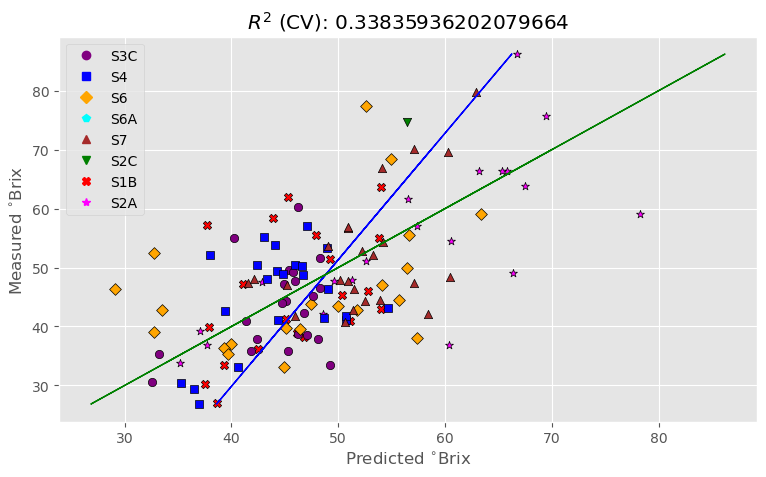

In [37]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RCN, y_RCN, 20)
file_name_sla = r'E:\wenqu\2026_root\CSV\RCN.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RCN,                         
                             ncomp, labels_RCN, file_name_sla)

## RCC


Optimised number of PLS components:  10
Wavelengths to be kept  22
Optimised MSEP  26.014835432874442

[469.78350109 470.93774529 454.85034878 503.01112233 454.21276665
 488.29066999 483.66532294 470.11096236 488.63441695 478.97617727
 513.1659902  503.01450515 492.40072474 475.85263229 456.91924968
 495.6405201  500.41540112 489.45650403 530.02268376 488.97366606
 462.11206077 451.30420576 442.17752276 456.78082778 478.19711312
 459.77424313 475.26008868 443.06387516 431.71237288 431.08905137
 434.53283946 463.3920763  412.47965937 458.04034569 468.68339228
 452.4472533  486.5510785  485.95736513 496.45654156 486.80430809
 448.36248552 475.74768179 487.77181845 453.92958009 462.50362323
 469.16235493 429.85700788 448.21171164 461.01711735 440.86780808
 452.27765191 434.99515859 437.80942017 457.6714023  445.01084008
 446.51823601 452.8448012  438.62541061 446.18620879 453.11773264
 451.49589328 448.59748973 465.32182892 448.53272311 451.63358529
 454.81991811 444.30482368 434.9175247

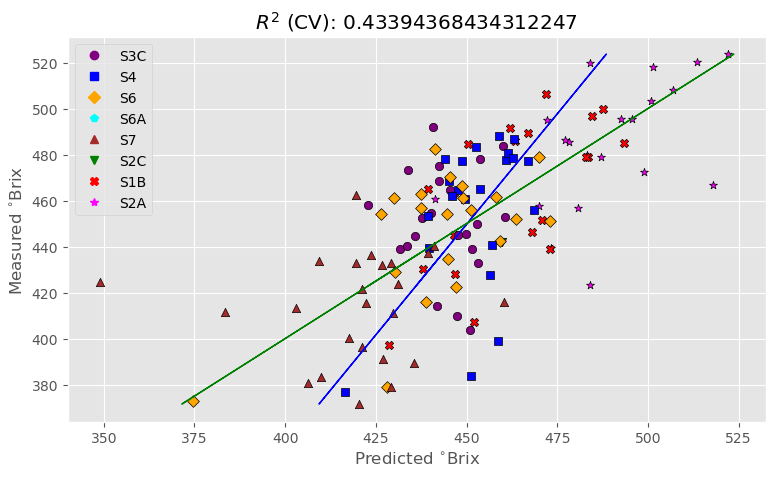

In [12]:
opt_Xc, ncomp, wav, sorted_ind = optimise_pls_band_component(x_RCC, y_RCC, 20)
file_name_sla = r'E:\wenqu\2026_root\CSV\RCC.csv'
simple_pls_cv_label_category(opt_Xc, 
                             y_RCC,                         
                             ncomp, labels_RCC, file_name_sla)

In [13]:
df_svc_ldmc['site'][96]

'S2A_Q28'

In [3]:
import pandas as pd

df1 = pd.read_csv(r"E:\wenqu\2026_root\soil core trait_full_edited.csv")
df2 = pd.read_csv(r"D:\wenqu\2024_data\Fw_2024_aboveground\2022_2024_spectral.csv")

# inner join (only matching rows)
df_joined = pd.merge(df1, df2, on="site", how="inner")

df_joined.to_csv(r"E:\wenqu\2026_root\root_trait.csv", index=False)


In [30]:
import pandas as pd
import numpy as np

# ===== 1. file paths =====
input_csv = r"D:\wenqu\2024_data\SVC\update3_vascular\spectral_trait_mean.csv"
# output_csv_all = r"D:\wenqu\2024_data\SVC\update3_vascular\PC_with_zscores.csv"
output_csv_clean = r"D:\wenqu\2024_data\SVC\update3_vascular\PN_without_zscores.csv"

# ===== 2. column name =====
col = "CWM_log10_LNC"   # <-- change this to your column name

# ===== 3. read csv =====
df = pd.read_csv(input_csv)

# make sure column is numeric
df[col] = pd.to_numeric(df[col], errors="coerce")

# ===== 4. compute z-score =====
mean = df[col].mean()
std = df[col].std()

df["z_score"] = (df[col] - mean) / std

# ===== 5. flag outliers (|z| > 3) =====
df["outlier"] = df["z_score"].abs() > 3

# ===== 6. remove outliers (optional) =====
df_clean = df[df["outlier"] == False]

# ===== 7. save results =====
# df.to_csv(output_csv_all, index=False)
df_clean.to_csv(output_csv_clean, index=False)

print("Done!")
print("Total rows:", len(df))
print("Outliers removed:", df["outlier"].sum())


Done!
Total rows: 138
Outliers removed: 1
